# Project Machine Learning for IOTs
Author: Yingshuo Xi, Ali Jahangiri

# 1 Data Loading

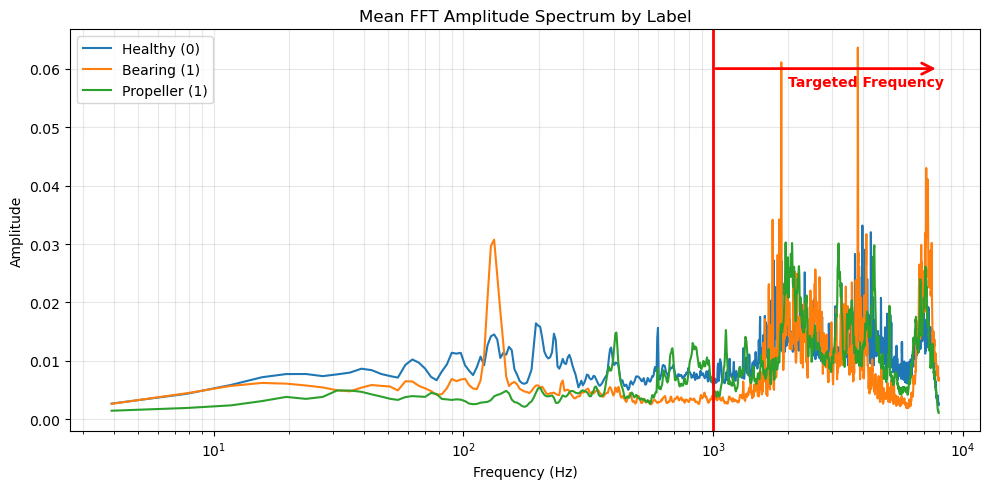

In [1]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

name = [ # Healthy
        # "Data/Healthy/M1/1400.wav",        # Not included due to different sampling rate
        "Data/Healthy/M1/1450.wav", "Data/Healthy/M1/1550.wav", "Data/Healthy/M1/1650.wav",
        "Data/Healthy/M1/1750.wav", "Data/Healthy/M1/1850.wav", "Data/Healthy/M1/1950.wav", "Data/Healthy/M1/2000.wav", 
        
        "Data/Healthy/M2/1400.wav", "Data/Healthy/M2/1450.wav", "Data/Healthy/M2/1550.wav", "Data/Healthy/M2/1650.wav",
        "Data/Healthy/M2/1750.wav", "Data/Healthy/M2/1850.wav", "Data/Healthy/M2/1950.wav", "Data/Healthy/M2/2000.wav", 

        "Data/Healthy/M3/1450.wav", "Data/Healthy/M3/1550.wav", "Data/Healthy/M3/1650.wav",
        "Data/Healthy/M3/1750.wav", "Data/Healthy/M3/1850.wav", "Data/Healthy/M3/1950.wav", 

        # Bearing
        "Data/Bearing/M4/1700.wav", "Data/Bearing/M4/1750.wav", "Data/Bearing/M4/1800.wav", "Data/Bearing/M4/1850.wav", 
        "Data/Bearing/M4/1900.wav", "Data/Bearing/M4/1950.wav", "Data/Bearing/M4/2000.wav",

        # Propeller
        "Data/Propeller/M1/1400.wav", "Data/Propeller/M1/1450.wav", "Data/Propeller/M1/1550.wav", "Data/Propeller/M1/1650.wav", 
        "Data/Propeller/M1/1750.wav", "Data/Propeller/M1/1850.wav",

        "Data/Propeller/M2/1400.wav", "Data/Propeller/M2/1450.wav", "Data/Propeller/M2/1550.wav", "Data/Propeller/M2/1650.wav", 
        "Data/Propeller/M2/1750.wav", "Data/Propeller/M2/1850.wav", "Data/Propeller/M2/1950.wav", "Data/Propeller/M2/2000.wav"
       ]
labels = [  # Healthy
            0, 0, 0,
            0, 0, 0, 0, 
            
            0, 0, 0, 0,
            0, 0, 0, 0, 
    
            0, 0, 0,
            0, 0, 0,

            # Bearing
            1, 1, 1, 1, 
            1, 1, 1,

            # Propeller
            2, 2, 2, 2,
            2, 2,
    
            2, 2, 2, 2,
            2, 2, 2, 2
           ]

# 0 = Train, 1 = Validation, 1 = Test, 2 = Not used
train_val_test_mark = [  # Healthy
            0, 1, 2,
            0, 3, 3, 3, 
            
            0, 1, 2, 0,
            0, 1, 2, 0, 
    
            0, 1, 2,
            0, 3, 3,

            # Bearing
            0, 1, 2, 0, 
            0, 1, 2,

            # Propeller
            0, 1, 2, 0,
            3, 3,
    
            0, 1, 2, 0,
            3, 3, 3, 3
           ]

def mean_amp_spectrum_by_segments(x, fs, n_fft=4096):
    x = x.astype(np.float64)
    x = x - np.mean(x)

    w = np.hanning(n_fft)

    # Segmentation
    n = len(x)
    if n < n_fft:
        x = np.pad(x, (0, n_fft - n))
        n = len(x)

    starts = np.arange(0, n - n_fft + 1, n_fft // 2)
    amps = []

    for s in starts:
        frame = x[s:s+n_fft] * w
        X = np.fft.rfft(frame, n=n_fft)

        # Amplitude Spectrum
        A = np.abs(X) / (np.sum(w) + 1e-12)
        amps.append(A)

    A_mean = np.mean(np.stack(amps, axis=0), axis=0)
    f = np.fft.rfftfreq(n_fft, d=1.0/fs)
    return f, A_mean

def plot_mean_fft_by_label(names, labels, n_fft=4096):
    spec_by_label = {0: [], 1: [], 2: []}
    f_ref = None
    fs_ref = None

    for path, lab in zip(names, labels):
        fs, data = wavfile.read(path)

        if data.ndim == 2:
            data = data.mean(axis=1)

        # Data Normalization
        eps = 1e-12
        data = data.astype(np.float64)
        data = (data - data.mean()) / (data.std() + eps)

        # Check the sampling rate
        if fs_ref is None:
            fs_ref = fs
        elif fs != fs_ref:
            raise ValueError(f"Sampling rate is difference")

        f, A_mean = mean_amp_spectrum_by_segments(data, fs, n_fft=n_fft)
        if f_ref is None:
            f_ref = f

        spec_by_label[int(lab)].append(A_mean)

    # Average by label
    A0 = np.mean(np.stack(spec_by_label[0], axis=0), axis=0) if len(spec_by_label[0]) else None
    A1 = np.mean(np.stack(spec_by_label[1], axis=0), axis=0) if len(spec_by_label[1]) else None
    A2 = np.mean(np.stack(spec_by_label[2], axis=0), axis=0) if len(spec_by_label[2]) else None

    plt.figure(figsize=(10, 5))
    if A0 is not None:
        plt.semilogx(f_ref[1:], A0[1:], label="Healthy (0)")
    if A1 is not None:
        plt.semilogx(f_ref[1:], A1[1:], label="Bearing (1)")
    if A2 is not None:
        plt.semilogx(f_ref[1:], A2[1:], label="Propeller (1)")

    plt.title("Mean FFT Amplitude Spectrum by Label")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    return fs

sampling_rate = plot_mean_fft_by_label(name, labels)
plt.axvline(x=1e3, color='red', linewidth=2)
plt.annotate('', xy=(8e3, 0.06), xytext=(1e3, 0.06), arrowprops=dict(arrowstyle='->', color='red', linewidth=2, mutation_scale=20))
plt.text(2e3, 0.057, "Targeted Frequency", color='red', fontsize=10, fontweight="bold")
plt.show()

In [2]:
import math

def min_samples_for_frequency(f0, sample_rate, K=5):
    L = K * sample_rate / f0
    return math.ceil(L)

f0 = 1000
K = 5

L = min_samples_for_frequency(f0, sampling_rate, K)
print(f"To capture enough cycles ({K}) of the frequency ({f0} Hz) based on the sampling rate ({sampling_rate} Hz), \033[1mthe minimal data points per sample: {L}\033[0m.")

To capture enough cycles (5) of the frequency (1000 Hz) based on the sampling rate (16000 Hz), the minimal data points per sample: 80.


In [3]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

segment_length = 80
downsampling_rate = 10
labels_value = (np.array(labels) < 1).astype(int)

def build_dataset(name, labels_value, mark, target_mark, mean_train = None, std_train = None):
    all_segments = []
    all_labels = []

    if not set(labels_value).issubset({0,1}):
        raise ValueError("Error: labels_value must contain only 0 and 1.")

    for i in range(len(name)):
        if mark[i] != target_mark:
            continue
            
        sample_rate, data = wavfile.read(name[i])
        if len(data.shape) == 2:
            data = data.mean(axis=1)
        
        # Data Self-Normalization
        eps = 1e-12
        mean = data.mean()
        std  = data.std()
        data = (data - mean) / (std + eps)

        # # Down Sampling
        # num_ds = len(data) // downsampling_rate
        # data = data[:num_ds * downsampling_rate]
        # data = data.reshape(-1, downsampling_rate)
        # data = data.mean(axis = 1)

        # Cut into pieces
        num_segments = len(data) // segment_length
        data = data[:num_segments * segment_length]
        segments = data.reshape(num_segments, segment_length)
        # print(name[i], segments.shape)
    
        labels = np.full(num_segments, labels_value[i], dtype=np.uint8)
        all_segments.append(segments)
        all_labels.append(labels)

    all_segments = np.vstack(all_segments)
    all_labels = np.concatenate(all_labels)
    print("Before shuffle:", all_segments.shape, all_labels.shape)
    
    indices = np.random.permutation(len(all_segments))
    all_segments = all_segments[indices]
    all_labels = all_labels[indices]
    print("After shuffle:", all_segments.shape, all_labels.shape)

    print(f"label(0) = {len(all_labels) - np.sum(all_labels)} ({(1 - np.sum(all_labels)/len(all_labels))*100:.2f}%), label(1) = {np.sum(all_labels)} ({(np.sum(all_labels)/len(all_labels))*100:.2f}%)")

    # # Normalization
    # eps = 1e-12
    # if target_mark == 0:  # Train
    #     mean_train = all_segments.mean(axis=0)
    #     std_train  = all_segments.std(axis=0)
    #     all_segments = (all_segments - mean_train) / (std_train + eps)
    # if target_mark == 1:  # Test
    #     all_segments = (all_segments - mean_train) / (std_train + eps)

    return all_segments, all_labels, mean_train, std_train

In [4]:
print("TRAIN: ")
train_X, train_y, mean_train, std_train = build_dataset(name, labels_value, train_val_test_mark, 0)
print("\nVALIDATION: ")
val_X, val_y, _, _ = build_dataset(name, labels_value, train_val_test_mark, 1, mean_train, std_train)
print("\nTEST: ")
test_X, test_y, _, _ = build_dataset(name, labels_value, train_val_test_mark, 2, mean_train, std_train)
# < 65536 (2^16), Use 2-byte-sequence number 

TRAIN: 
Before shuffle: (30825, 80) (30825,)
After shuffle: (30825, 80) (30825,)
label(0) = 14425 (46.80%), label(1) = 16400 (53.20%)

VALIDATION: 
Before shuffle: (16472, 80) (16472,)
After shuffle: (16472, 80) (16472,)
label(0) = 8236 (50.00%), label(1) = 8236 (50.00%)

TEST: 
Before shuffle: (16392, 80) (16392,)
After shuffle: (16392, 80) (16392,)
label(0) = 8186 (49.94%), label(1) = 8206 (50.06%)


# 2 Pure Python Code
Here you can get the result from pure Python code, which is the same as in STM32

## 2.1 Backpropagation

epoch 0, step 2000: avg_loss=0.752534, acc=0.5230
epoch 0, step 4000: avg_loss=0.695040, acc=0.5485
epoch 0, step 6000: avg_loss=0.685009, acc=0.5735
epoch 0, step 8000: avg_loss=0.665299, acc=0.6015
epoch 0, step 10000: avg_loss=0.661546, acc=0.6070
epoch 0, step 12000: avg_loss=0.648465, acc=0.6230
epoch 0, step 14000: avg_loss=0.630028, acc=0.6430
epoch 0, step 16000: avg_loss=0.641677, acc=0.6385
epoch 0, step 18000: avg_loss=0.622405, acc=0.6455
epoch 0, step 20000: avg_loss=0.614187, acc=0.6550
epoch 0, step 22000: avg_loss=0.614341, acc=0.6705
epoch 0, step 24000: avg_loss=0.593540, acc=0.6910
epoch 0, step 26000: avg_loss=0.587040, acc=0.6930
epoch 0, step 28000: avg_loss=0.565573, acc=0.7060
epoch 0, step 30000: avg_loss=0.545767, acc=0.7275
Train Acc: 0.732133
Validation Acc: 0.547778
Test Acc: 0.640312
epoch 1, step 2000: avg_loss=0.544521, acc=0.7340
epoch 1, step 4000: avg_loss=0.527268, acc=0.7540
epoch 1, step 6000: avg_loss=0.537083, acc=0.7390
epoch 1, step 8000: avg_l

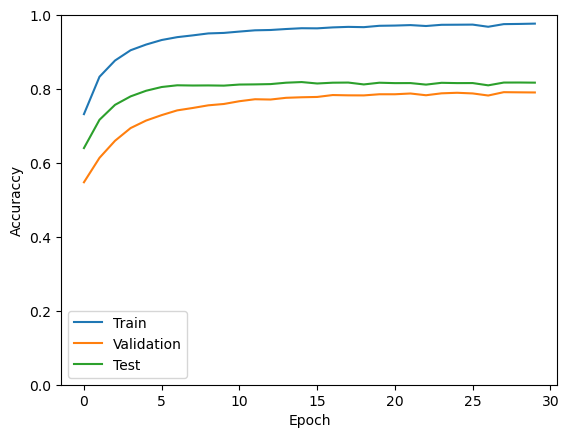

In [31]:
import numpy as np

IN = 80
H1 = 40
H2 = 20

def relu(x):
    return np.maximum(0.0, x)

def relu_grad(x):
    return (x > 0.0).astype(np.float64)

def sigmoid(z):
    z = np.float64(z)
    if z >= 0.0:
        ez = np.exp(-z)
        return 1.0 / (1.0 + ez)
    else:
        ez = np.exp(z)
        return ez / (1.0 + ez)

class STM32NN:
    def __init__(self, lr=1e-3):
        self.lr = np.float64(lr)

        limit1 = np.sqrt(6.0 / IN)
        self.W1 = np.random.uniform(-limit1, limit1, (H1, IN))
        self.b1 = np.zeros(H1)
        
        limit2 = np.sqrt(6.0 / H1)
        self.W2 = np.random.uniform(-limit2, limit2, (H2, H1))
        self.b2 = np.zeros(H2)
        
        limit3 = np.sqrt(6.0 / H2)
        self.W3 = np.random.uniform(-limit3, limit3, H2)
        self.b3 = 0.0

    def predict(self, x):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        before1 = self.b1 + self.W1 @ x
        after1  = relu(before1)

        before2 = self.b2 + self.W2 @ after1
        after2  = relu(before2)

        before3 = self.b3 + self.W3 @ after2
        return sigmoid(before3)

    def train_one(self, x, y_int8):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        y = np.float64(0.0 if int(y_int8) == 0 else 1.0)

        # Forward
        before1 = self.b1 + self.W1 @ x
        after1  = relu(before1)

        before2 = self.b2 + self.W2 @ after1
        after2  = relu(before2)

        before3 = self.b3 + self.W3 @ after2
        after3  = sigmoid(before3)

        # Loss
        eps  = np.float64(1e-12)
        loss = -(y * np.log(after3 + eps) + (1.0 - y) * np.log(1.0 - after3 + eps))

        # Backprop
        d_before3 = after3 - y
        d_b3 = d_before3

        d_before2 = (d_before3 * self.W3) * relu_grad(before2)

        d_before1 = (self.W2.T @ d_before2) * relu_grad(before1)

        # SGD update
        self.W3 -= self.lr * (d_before3 * after2)
        self.b3 -= self.lr * d_b3

        self.b2 -= self.lr * d_before2
        self.W2 -= self.lr * (d_before2[:, None] * after1[None, :])

        self.b1 -= self.lr * d_before1
        self.W1 -= self.lr * (d_before1[:, None] * x[None, :])

        return float(loss)



import numpy as np

nn = STM32NN(lr=1e-3)

log_size = 2000
epochs = 30

train_log = []
validation_log = []
test_log = []

for epoch in range(epochs):
    running_loss = 0.0
    running_correct = 0
    
    for i in range(len(train_X)):
        
        prob = nn.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        
        if pred == int(train_y[i]):
            running_correct += 1

        loss = nn.train_one(train_X[i], train_y[i])
        running_loss += loss
        
        if (i + 1) % log_size == 0:
            avg_loss = running_loss / log_size
            acc = running_correct / log_size
            
            print(f"epoch {epoch}, step {i+1}: "
                  f"avg_loss={avg_loss:.6f}, acc={acc:.4f}")
            
            running_loss = 0.0
            running_correct = 0

    train_correct = 0
    preds = []
    for i in range (len(train_X)):
        prob = nn.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(train_y[i]) != 0 else 0
        if pred == true:
            train_correct += 1
    train_log.append(train_correct/len(train_X))
    print(f"\033[1mTrain Acc: {train_correct/len(train_X):.6f}\033[0m")

    val_correct = 0
    preds = []
    for i in range (len(val_X)):
        prob = nn.predict(val_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(val_y[i]) != 0 else 0
        if pred == true:
            val_correct += 1
    validation_log.append(val_correct/len(val_X))
    print(f"\033[1mValidation Acc: {val_correct/len(val_X):.6f}\033[0m")

    test_correct = 0
    preds = []
    test_preds = []
    for i in range (len(test_X)):
        prob = nn.predict(test_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        if pred == int(test_y[i]):
            test_correct += 1
    test_log.append(test_correct/len(test_X))
    print(f"\033[1mTest Acc: {test_correct/len(test_X):.6f}\033[0m")


plt.figure()
plt.plot(train_log, label='Train')
plt.plot(validation_log, label='Validation')
plt.plot(test_log, label='Test')
plt.ylim(0, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuraccy')
plt.legend()
plt.show()

## 2.2 Forward-Forward

epoch 0, step 2000: avg_loss=72.953284, acc=0.5250
epoch 0, step 4000: avg_loss=57.045734, acc=0.5495
epoch 0, step 6000: avg_loss=56.890673, acc=0.5670
epoch 0, step 8000: avg_loss=51.495450, acc=0.5905
epoch 0, step 10000: avg_loss=54.356063, acc=0.5790
epoch 0, step 12000: avg_loss=45.567974, acc=0.6205
epoch 0, step 14000: avg_loss=39.023626, acc=0.5995
epoch 0, step 16000: avg_loss=52.712811, acc=0.6000
epoch 0, step 18000: avg_loss=35.926009, acc=0.6415
epoch 0, step 20000: avg_loss=41.965235, acc=0.6470
epoch 0, step 22000: avg_loss=40.118742, acc=0.6415
epoch 0, step 24000: avg_loss=36.813591, acc=0.6615
epoch 0, step 26000: avg_loss=38.261806, acc=0.6725
epoch 0, step 28000: avg_loss=33.157394, acc=0.6595
epoch 0, step 30000: avg_loss=26.056987, acc=0.6760
Train Acc: 0.686878
Validation Acc: 0.553606
Test Acc: 0.624207
epoch 1, step 2000: avg_loss=37.003436, acc=0.6750
epoch 1, step 4000: avg_loss=29.140085, acc=0.6950
epoch 1, step 6000: avg_loss=29.538814, acc=0.6920
epoch 1

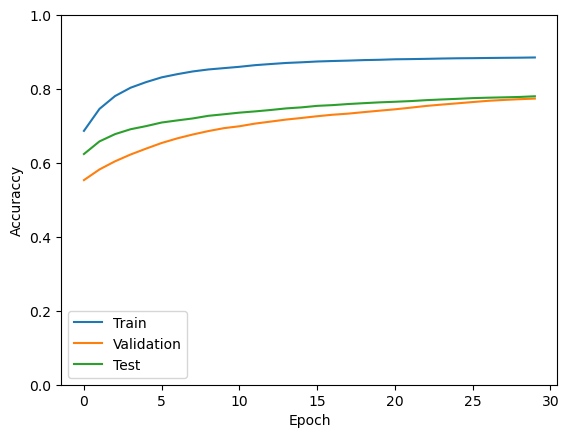

In [32]:
import numpy as np

IN  = 80
H1  = 80
H2  = 80
H3  = 80

def relu(x):
    return np.maximum(0.0, x)

def relu_grad(x):
    return (x > 0.0).astype(np.float64)

def sigmoid_scalar(z):
    z = np.float64(z)
    if z >= 0.0:
        ez = np.exp(-z)
        return 1.0 / (1.0 + ez)
    else:
        ez = np.exp(z)
        return ez / (1.0 + ez)

class STM32FFNN:
    def __init__(self, lr=1e-3):
        self.lr = np.float64(lr)
        self.theta1 = np.float64(H1)
        self.theta2 = np.float64(H2)
        self.theta3 = np.float64(H3)

        lim1 = np.sqrt(6.0 / IN)
        lim2 = np.sqrt(6.0 / H1)
        lim3 = np.sqrt(6.0 / H2)

        self.W1 = np.random.uniform(-lim1, lim1, (H1, IN)).astype(np.float64)
        self.b1 = np.zeros(H1, dtype=np.float64)

        self.W2 = np.random.uniform(-lim2, lim2, (H2, H1)).astype(np.float64)
        self.b2 = np.zeros(H2, dtype=np.float64)

        self.W3 = np.random.uniform(-lim3, lim3, (H3, H2)).astype(np.float64)
        self.b3 = np.zeros(H3, dtype=np.float64)

    def predict(self, x):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)

        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)

        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)

        goodness_1 = np.sum(a1 * a1)
        goodness_2 = np.sum(a2 * a2)
        goodness_3 = np.sum(a3 * a3)

        GOODNESS = goodness_1 + goodness_2 + goodness_3
        THETA = self.theta1 + self.theta2 + self.theta3

        return float(sigmoid_scalar(GOODNESS - THETA))

    def nn_ff_train_one(self, x, y_int8):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        y_int = 1 if int(y_int8) != 0 else 0
        loss_sum = np.float64(0.0)

        # Layer1
        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)
        goodness_1 = np.sum(a1 * a1)

        tmp = (self.theta1 - goodness_1) if y_int else (goodness_1 - self.theta1)
        if tmp > (11.9 - 6.9):
            loss_1 = tmp
        elif tmp < (6.9 - 11.9):
            loss_1 = np.exp(tmp)
        else:
            loss_1 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_1

        dL_dg = (-sigmoid_scalar(self.theta1 - goodness_1)) if y_int else (sigmoid_scalar(goodness_1 - self.theta1))

        t1 = dL_dg * (2.0 * a1) * relu_grad(z1)
        self.b1 -= self.lr * t1
        self.W1 -= self.lr * np.outer(t1, x)

        a1_next = relu(self.b1 + self.W1 @ x)
        # a1_next = a1

        # Layer2
        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)
        goodness_2 = np.sum(a2 * a2)

        tmp = (self.theta2 - goodness_2) if y_int else (goodness_2 - self.theta2)
        if tmp > (11.9 - 6.9):
            loss_2 = tmp
        elif tmp < (6.9 - 11.9):
            loss_2 = np.exp(tmp)
        else:
            loss_2 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_2

        dL_dg = (-sigmoid_scalar(self.theta2 - goodness_2)) if y_int else (sigmoid_scalar(goodness_2 - self.theta2))

        t2 = dL_dg * (2.0 * a2) * relu_grad(z2)
        self.b2 -= self.lr * t2
        self.W2 -= self.lr * np.outer(t2, a1_next)

        a2_next = relu(self.b2 + self.W2 @ a1_next)
        # a2_next = a2

        # Layer3
        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)
        goodness_3 = np.sum(a3 * a3)

        tmp = (self.theta3 - goodness_3) if y_int else (goodness_3 - self.theta3)
        if tmp > (11.9 - 6.9):
            loss_3 = tmp
        elif tmp < (6.9 - 11.9):
            loss_3 = np.exp(tmp)
        else:
            loss_3 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_3

        dL_dg = (-sigmoid_scalar(self.theta3 - goodness_3)) if y_int else (sigmoid_scalar(goodness_3 - self.theta3))

        t3 = dL_dg * (2.0 * a3) * relu_grad(z3)
        self.b3 -= self.lr * t3
        self.W3 -= self.lr * np.outer(t3, a2_next)

        return float(loss_sum)


ff = STM32FFNN(lr=3e-5)

epochs = 30
log_size = 2000

train_log = []
validation_log = []
test_log = []

for epoch in range(epochs):
    running_loss = 0.0
    running_correct = 0

    for i in range(len(train_X)):

        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        true = 1 if int(train_y[i]) != 0 else 0
        running_correct += (pred == true)

        loss = ff.nn_ff_train_one(train_X[i], train_y[i])
        running_loss += loss

        if (i + 1) % log_size == 0:
            print(f"epoch {epoch}, step {i+1}: "
                  f"avg_loss={running_loss/log_size:.6f}, acc={running_correct/log_size:.4f}")
            running_loss = 0.0
            running_correct = 0

    train_correct = 0
    preds = []
    for i in range (len(train_X)):
        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(train_y[i]) != 0 else 0
        if pred == true:
            train_correct += 1
    train_log.append(train_correct/len(train_X))
    print(f"\033[1mTrain Acc: {train_correct/len(train_X):.6f}\033[0m")

    val_correct = 0
    preds = []
    for i in range (len(val_X)):
        prob = ff.predict(val_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(val_y[i]) != 0 else 0
        if pred == true:
            val_correct += 1
    validation_log.append(val_correct/len(val_X))
    print(f"\033[1mValidation Acc: {val_correct/len(val_X):.6f}\033[0m")

    test_correct = 0
    preds = []
    test_preds = []
    for i in range (len(test_X)):
        prob = ff.predict(test_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        if pred == int(test_y[i]):
            test_correct += 1
    test_log.append(test_correct/len(test_X))
    print(f"\033[1mTest Acc: {test_correct/len(test_X):.6f}\033[0m")


plt.figure()
plt.plot(train_log, label='Train')
plt.plot(validation_log, label='Validation')
plt.plot(test_log, label='Test')
plt.ylim(0, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuraccy')
plt.legend()
plt.show()

epoch 0, step 2000: avg_loss=64.670753, acc=0.5510
epoch 0, step 4000: avg_loss=48.430959, acc=0.6100
epoch 0, step 6000: avg_loss=44.077623, acc=0.6280
epoch 0, step 8000: avg_loss=42.041711, acc=0.6635
epoch 0, step 10000: avg_loss=37.766437, acc=0.6615
epoch 0, step 12000: avg_loss=31.155969, acc=0.6990
epoch 0, step 14000: avg_loss=26.250808, acc=0.7070
epoch 0, step 16000: avg_loss=36.789541, acc=0.7050
epoch 0, step 18000: avg_loss=23.865788, acc=0.7175
epoch 0, step 20000: avg_loss=24.892528, acc=0.7375
epoch 0, step 22000: avg_loss=24.774516, acc=0.7430
epoch 0, step 24000: avg_loss=23.164680, acc=0.7520
epoch 0, step 26000: avg_loss=23.769439, acc=0.7575
epoch 0, step 28000: avg_loss=18.937724, acc=0.7545
epoch 0, step 30000: avg_loss=14.789043, acc=0.7710
Train Acc: 0.779270
Validation Acc: 0.620386
Test Acc: 0.680210
epoch 1, step 2000: avg_loss=17.952415, acc=0.7800
epoch 1, step 4000: avg_loss=16.143985, acc=0.7900
epoch 1, step 6000: avg_loss=15.086613, acc=0.7835
epoch 1

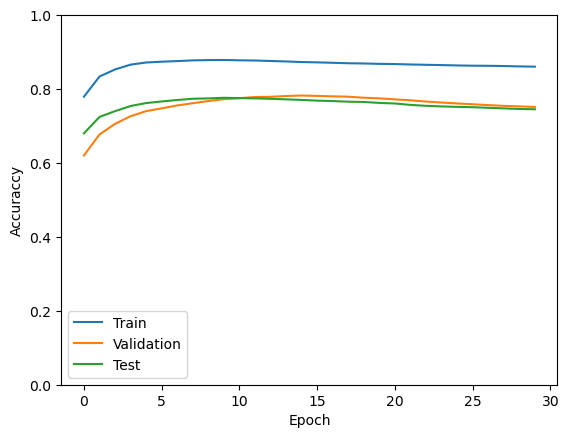

In [33]:
import numpy as np

IN  = 80
H1  = 80
H2  = 80
H3  = 80

def relu(x):
    return np.maximum(0.0, x)

def relu_grad(x):
    return (x > 0.0).astype(np.float64)

def sigmoid_scalar(z):
    z = np.float64(z)
    if z >= 0.0:
        ez = np.exp(-z)
        return 1.0 / (1.0 + ez)
    else:
        ez = np.exp(z)
        return ez / (1.0 + ez)

class STM32FFNN:
    def __init__(self, lr=1e-3):
        self.lr = np.float64(lr)
        self.theta1 = np.float64(H1)
        self.theta2 = np.float64(H2)
        self.theta3 = np.float64(H3)

        lim1 = np.sqrt(6.0 / IN)
        lim2 = np.sqrt(6.0 / H1)
        lim3 = np.sqrt(6.0 / H2)

        self.W1 = np.random.uniform(-lim1, lim1, (H1, IN)).astype(np.float64)
        self.b1 = np.zeros(H1, dtype=np.float64)

        self.W2 = np.random.uniform(-lim2, lim2, (H2, H1)).astype(np.float64)
        self.b2 = np.zeros(H2, dtype=np.float64)

        self.W3 = np.random.uniform(-lim3, lim3, (H3, H2)).astype(np.float64)
        self.b3 = np.zeros(H3, dtype=np.float64)

    def predict(self, x):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)

        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)

        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)

        goodness_1 = np.sum(a1 * a1)
        goodness_2 = np.sum(a2 * a2)
        goodness_3 = np.sum(a3 * a3)

        GOODNESS = goodness_1 + goodness_2 + goodness_3
        THETA = self.theta1 + self.theta2 + self.theta3

        return float(sigmoid_scalar(GOODNESS - THETA))

    def nn_ff_train_one(self, x, y_int8):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        y_int = 1 if int(y_int8) != 0 else 0
        loss_sum = np.float64(0.0)

        # Layer1
        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)
        goodness_1 = np.sum(a1 * a1)

        tmp = (self.theta1 - goodness_1) if y_int else (goodness_1 - self.theta1)
        if tmp > (11.9 - 6.9):
            loss_1 = tmp
        elif tmp < (6.9 - 11.9):
            loss_1 = np.exp(tmp)
        else:
            loss_1 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_1

        dL_dg = (-sigmoid_scalar(self.theta1 - goodness_1)) if y_int else (sigmoid_scalar(goodness_1 - self.theta1))

        t1 = dL_dg * (2.0 * a1) * relu_grad(z1)
        self.b1 -= self.lr * t1
        self.W1 -= self.lr * np.outer(t1, x)

        a1_next = relu(self.b1 + self.W1 @ x)
        # a1_next = a1

        # Layer2
        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)
        goodness_2 = np.sum(a2 * a2)

        tmp = (self.theta2 - goodness_2) if y_int else (goodness_2 - self.theta2)
        if tmp > (11.9 - 6.9):
            loss_2 = tmp
        elif tmp < (6.9 - 11.9):
            loss_2 = np.exp(tmp)
        else:
            loss_2 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_2

        dL_dg = (-sigmoid_scalar(self.theta2 - goodness_2)) if y_int else (sigmoid_scalar(goodness_2 - self.theta2))

        t2 = dL_dg * (2.0 * a2) * relu_grad(z2)
        self.b2 -= self.lr * t2
        self.W2 -= self.lr * np.outer(t2, a1_next)

        a2_next = relu(self.b2 + self.W2 @ a1_next)
        # a2_next = a2

        # Layer3
        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)
        goodness_3 = np.sum(a3 * a3)

        tmp = (self.theta3 - goodness_3) if y_int else (goodness_3 - self.theta3)
        if tmp > (11.9 - 6.9):
            loss_3 = tmp
        elif tmp < (6.9 - 11.9):
            loss_3 = np.exp(tmp)
        else:
            loss_3 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_3

        dL_dg = (-sigmoid_scalar(self.theta3 - goodness_3)) if y_int else (sigmoid_scalar(goodness_3 - self.theta3))

        t3 = dL_dg * (2.0 * a3) * relu_grad(z3)
        self.b3 -= self.lr * t3
        self.W3 -= self.lr * np.outer(t3, a2_next)

        return float(loss_sum)


ff = STM32FFNN(lr=1e-4)

epochs = 30
log_size = 2000

train_log = []
validation_log = []
test_log = []

for epoch in range(epochs):
    running_loss = 0.0
    running_correct = 0

    for i in range(len(train_X)):

        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        true = 1 if int(train_y[i]) != 0 else 0
        running_correct += (pred == true)

        loss = ff.nn_ff_train_one(train_X[i], train_y[i])
        running_loss += loss

        if (i + 1) % log_size == 0:
            print(f"epoch {epoch}, step {i+1}: "
                  f"avg_loss={running_loss/log_size:.6f}, acc={running_correct/log_size:.4f}")
            running_loss = 0.0
            running_correct = 0

    train_correct = 0
    preds = []
    for i in range (len(train_X)):
        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(train_y[i]) != 0 else 0
        if pred == true:
            train_correct += 1
    train_log.append(train_correct/len(train_X))
    print(f"\033[1mTrain Acc: {train_correct/len(train_X):.6f}\033[0m")

    val_correct = 0
    preds = []
    for i in range (len(val_X)):
        prob = ff.predict(val_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(val_y[i]) != 0 else 0
        if pred == true:
            val_correct += 1
    validation_log.append(val_correct/len(val_X))
    print(f"\033[1mValidation Acc: {val_correct/len(val_X):.6f}\033[0m")

    test_correct = 0
    preds = []
    test_preds = []
    for i in range (len(test_X)):
        prob = ff.predict(test_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        if pred == int(test_y[i]):
            test_correct += 1
    test_log.append(test_correct/len(test_X))
    print(f"\033[1mTest Acc: {test_correct/len(test_X):.6f}\033[0m")


plt.figure()
plt.plot(train_log, label='Train')
plt.plot(validation_log, label='Validation')
plt.plot(test_log, label='Test')
plt.ylim(0, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuraccy')
plt.legend()
plt.show()

epoch 0, step 2000: avg_loss=26.689005, acc=0.5300
epoch 0, step 4000: avg_loss=21.156226, acc=0.5470
epoch 0, step 6000: avg_loss=20.144235, acc=0.5525
epoch 0, step 8000: avg_loss=21.032028, acc=0.5740
epoch 0, step 10000: avg_loss=21.307206, acc=0.5685
epoch 0, step 12000: avg_loss=17.322933, acc=0.5865
epoch 0, step 14000: avg_loss=16.004054, acc=0.5970
epoch 0, step 16000: avg_loss=19.257201, acc=0.5845
epoch 0, step 18000: avg_loss=14.224360, acc=0.6175
epoch 0, step 20000: avg_loss=16.842491, acc=0.6150
epoch 0, step 22000: avg_loss=15.433169, acc=0.6005
epoch 0, step 24000: avg_loss=14.516251, acc=0.6190
epoch 0, step 26000: avg_loss=15.926450, acc=0.6455
epoch 0, step 28000: avg_loss=13.825884, acc=0.6105
epoch 0, step 30000: avg_loss=10.699417, acc=0.6455
Train Acc: 0.651873
Validation Acc: 0.555427
Test Acc: 0.625915
epoch 1, step 2000: avg_loss=14.564674, acc=0.6540
epoch 1, step 4000: avg_loss=11.754816, acc=0.6660
epoch 1, step 6000: avg_loss=11.622157, acc=0.6530
epoch 1

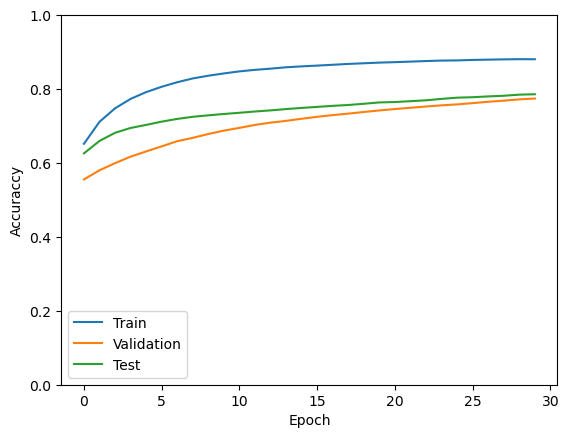

In [34]:
import numpy as np

IN  = 80
H1  = 40
H2  = 20
H3  = 20

def relu(x):
    return np.maximum(0.0, x)

def relu_grad(x):
    return (x > 0.0).astype(np.float64)

def sigmoid_scalar(z):
    z = np.float64(z)
    if z >= 0.0:
        ez = np.exp(-z)
        return 1.0 / (1.0 + ez)
    else:
        ez = np.exp(z)
        return ez / (1.0 + ez)

class STM32FFNN:
    def __init__(self, lr=1e-3):
        self.lr = np.float64(lr)
        self.theta1 = np.float64(H1)
        self.theta2 = np.float64(H2)
        self.theta3 = np.float64(H3)

        lim1 = np.sqrt(6.0 / IN)
        lim2 = np.sqrt(6.0 / H1)
        lim3 = np.sqrt(6.0 / H2)

        self.W1 = np.random.uniform(-lim1, lim1, (H1, IN)).astype(np.float64)
        self.b1 = np.zeros(H1, dtype=np.float64)

        self.W2 = np.random.uniform(-lim2, lim2, (H2, H1)).astype(np.float64)
        self.b2 = np.zeros(H2, dtype=np.float64)

        self.W3 = np.random.uniform(-lim3, lim3, (H3, H2)).astype(np.float64)
        self.b3 = np.zeros(H3, dtype=np.float64)

    def predict(self, x):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)

        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)

        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)

        goodness_1 = np.sum(a1 * a1)
        goodness_2 = np.sum(a2 * a2)
        goodness_3 = np.sum(a3 * a3)

        GOODNESS = goodness_1 + goodness_2 + goodness_3
        THETA = self.theta1 + self.theta2 + self.theta3

        return float(sigmoid_scalar(GOODNESS - THETA))

    def nn_ff_train_one(self, x, y_int8):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        y_int = 1 if int(y_int8) != 0 else 0
        loss_sum = np.float64(0.0)

        # Layer1
        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)
        goodness_1 = np.sum(a1 * a1)

        tmp = (self.theta1 - goodness_1) if y_int else (goodness_1 - self.theta1)
        if tmp > (11.9 - 6.9):
            loss_1 = tmp
        elif tmp < (6.9 - 11.9):
            loss_1 = np.exp(tmp)
        else:
            loss_1 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_1

        dL_dg = (-sigmoid_scalar(self.theta1 - goodness_1)) if y_int else (sigmoid_scalar(goodness_1 - self.theta1))

        t1 = dL_dg * (2.0 * a1) * relu_grad(z1)
        self.b1 -= self.lr * t1
        self.W1 -= self.lr * np.outer(t1, x)

        a1_next = relu(self.b1 + self.W1 @ x)
        # a1_next = a1

        # Layer2
        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)
        goodness_2 = np.sum(a2 * a2)

        tmp = (self.theta2 - goodness_2) if y_int else (goodness_2 - self.theta2)
        if tmp > (11.9 - 6.9):
            loss_2 = tmp
        elif tmp < (6.9 - 11.9):
            loss_2 = np.exp(tmp)
        else:
            loss_2 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_2

        dL_dg = (-sigmoid_scalar(self.theta2 - goodness_2)) if y_int else (sigmoid_scalar(goodness_2 - self.theta2))

        t2 = dL_dg * (2.0 * a2) * relu_grad(z2)
        self.b2 -= self.lr * t2
        self.W2 -= self.lr * np.outer(t2, a1_next)

        a2_next = relu(self.b2 + self.W2 @ a1_next)
        # a2_next = a2

        # Layer3
        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)
        goodness_3 = np.sum(a3 * a3)

        tmp = (self.theta3 - goodness_3) if y_int else (goodness_3 - self.theta3)
        if tmp > (11.9 - 6.9):
            loss_3 = tmp
        elif tmp < (6.9 - 11.9):
            loss_3 = np.exp(tmp)
        else:
            loss_3 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_3

        dL_dg = (-sigmoid_scalar(self.theta3 - goodness_3)) if y_int else (sigmoid_scalar(goodness_3 - self.theta3))

        t3 = dL_dg * (2.0 * a3) * relu_grad(z3)
        self.b3 -= self.lr * t3
        self.W3 -= self.lr * np.outer(t3, a2_next)

        return float(loss_sum)


ff = STM32FFNN(lr=3e-5)

epochs = 30
log_size = 2000

train_log = []
validation_log = []
test_log = []

for epoch in range(epochs):
    running_loss = 0.0
    running_correct = 0

    for i in range(len(train_X)):

        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        true = 1 if int(train_y[i]) != 0 else 0
        running_correct += (pred == true)

        loss = ff.nn_ff_train_one(train_X[i], train_y[i])
        running_loss += loss

        if (i + 1) % log_size == 0:
            print(f"epoch {epoch}, step {i+1}: "
                  f"avg_loss={running_loss/log_size:.6f}, acc={running_correct/log_size:.4f}")
            running_loss = 0.0
            running_correct = 0

    train_correct = 0
    preds = []
    for i in range (len(train_X)):
        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(train_y[i]) != 0 else 0
        if pred == true:
            train_correct += 1
    train_log.append(train_correct/len(train_X))
    print(f"\033[1mTrain Acc: {train_correct/len(train_X):.6f}\033[0m")

    val_correct = 0
    preds = []
    for i in range (len(val_X)):
        prob = ff.predict(val_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(val_y[i]) != 0 else 0
        if pred == true:
            val_correct += 1
    validation_log.append(val_correct/len(val_X))
    print(f"\033[1mValidation Acc: {val_correct/len(val_X):.6f}\033[0m")

    test_correct = 0
    preds = []
    test_preds = []
    for i in range (len(test_X)):
        prob = ff.predict(test_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        if pred == int(test_y[i]):
            test_correct += 1
    test_log.append(test_correct/len(test_X))
    print(f"\033[1mTest Acc: {test_correct/len(test_X):.6f}\033[0m")


plt.figure()
plt.plot(train_log, label='Train')
plt.plot(validation_log, label='Validation')
plt.plot(test_log, label='Test')
plt.ylim(0, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuraccy')
plt.legend()
plt.show()

epoch 0, step 2000: avg_loss=26.708361, acc=0.5440
epoch 0, step 4000: avg_loss=18.633152, acc=0.5790
epoch 0, step 6000: avg_loss=17.690833, acc=0.5860
epoch 0, step 8000: avg_loss=16.778431, acc=0.6320
epoch 0, step 10000: avg_loss=15.691417, acc=0.6250
epoch 0, step 12000: avg_loss=12.924472, acc=0.6600
epoch 0, step 14000: avg_loss=11.337423, acc=0.6705
epoch 0, step 16000: avg_loss=14.063177, acc=0.6680
epoch 0, step 18000: avg_loss=10.074935, acc=0.6945
epoch 0, step 20000: avg_loss=11.322036, acc=0.7070
epoch 0, step 22000: avg_loss=10.192877, acc=0.7125
epoch 0, step 24000: avg_loss=9.601807, acc=0.7200
epoch 0, step 26000: avg_loss=8.981582, acc=0.7475
epoch 0, step 28000: avg_loss=7.437974, acc=0.7395
epoch 0, step 30000: avg_loss=5.656949, acc=0.7650
Train Acc: 0.759935
Validation Acc: 0.596892
Test Acc: 0.670083
epoch 1, step 2000: avg_loss=7.691926, acc=0.7620
epoch 1, step 4000: avg_loss=6.442627, acc=0.7645
epoch 1, step 6000: avg_loss=6.217694, acc=0.7685
epoch 1, step 

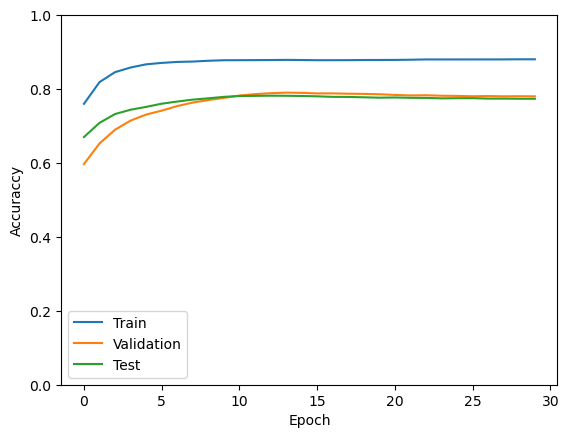

In [35]:
import numpy as np

IN  = 80
H1  = 40
H2  = 20
H3  = 20

def relu(x):
    return np.maximum(0.0, x)

def relu_grad(x):
    return (x > 0.0).astype(np.float64)

def sigmoid_scalar(z):
    z = np.float64(z)
    if z >= 0.0:
        ez = np.exp(-z)
        return 1.0 / (1.0 + ez)
    else:
        ez = np.exp(z)
        return ez / (1.0 + ez)

class STM32FFNN:
    def __init__(self, lr=1e-3):
        self.lr = np.float64(lr)
        self.theta1 = np.float64(H1)
        self.theta2 = np.float64(H2)
        self.theta3 = np.float64(H3)

        lim1 = np.sqrt(6.0 / IN)
        lim2 = np.sqrt(6.0 / H1)
        lim3 = np.sqrt(6.0 / H2)

        self.W1 = np.random.uniform(-lim1, lim1, (H1, IN)).astype(np.float64)
        self.b1 = np.zeros(H1, dtype=np.float64)

        self.W2 = np.random.uniform(-lim2, lim2, (H2, H1)).astype(np.float64)
        self.b2 = np.zeros(H2, dtype=np.float64)

        self.W3 = np.random.uniform(-lim3, lim3, (H3, H2)).astype(np.float64)
        self.b3 = np.zeros(H3, dtype=np.float64)

    def predict(self, x):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)

        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)

        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)

        goodness_1 = np.sum(a1 * a1)
        goodness_2 = np.sum(a2 * a2)
        goodness_3 = np.sum(a3 * a3)

        GOODNESS = goodness_1 + goodness_2 + goodness_3
        THETA = self.theta1 + self.theta2 + self.theta3

        return float(sigmoid_scalar(GOODNESS - THETA))

    def nn_ff_train_one(self, x, y_int8):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        y_int = 1 if int(y_int8) != 0 else 0
        loss_sum = np.float64(0.0)

        # Layer1
        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)
        goodness_1 = np.sum(a1 * a1)

        tmp = (self.theta1 - goodness_1) if y_int else (goodness_1 - self.theta1)
        if tmp > (11.9 - 6.9):
            loss_1 = tmp
        elif tmp < (6.9 - 11.9):
            loss_1 = np.exp(tmp)
        else:
            loss_1 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_1

        dL_dg = (-sigmoid_scalar(self.theta1 - goodness_1)) if y_int else (sigmoid_scalar(goodness_1 - self.theta1))

        t1 = dL_dg * (2.0 * a1) * relu_grad(z1)
        self.b1 -= self.lr * t1
        self.W1 -= self.lr * np.outer(t1, x)

        a1_next = relu(self.b1 + self.W1 @ x)
        # a1_next = a1

        # Layer2
        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)
        goodness_2 = np.sum(a2 * a2)

        tmp = (self.theta2 - goodness_2) if y_int else (goodness_2 - self.theta2)
        if tmp > (11.9 - 6.9):
            loss_2 = tmp
        elif tmp < (6.9 - 11.9):
            loss_2 = np.exp(tmp)
        else:
            loss_2 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_2

        dL_dg = (-sigmoid_scalar(self.theta2 - goodness_2)) if y_int else (sigmoid_scalar(goodness_2 - self.theta2))

        t2 = dL_dg * (2.0 * a2) * relu_grad(z2)
        self.b2 -= self.lr * t2
        self.W2 -= self.lr * np.outer(t2, a1_next)

        a2_next = relu(self.b2 + self.W2 @ a1_next)
        # a2_next = a2

        # Layer3
        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)
        goodness_3 = np.sum(a3 * a3)

        tmp = (self.theta3 - goodness_3) if y_int else (goodness_3 - self.theta3)
        if tmp > (11.9 - 6.9):
            loss_3 = tmp
        elif tmp < (6.9 - 11.9):
            loss_3 = np.exp(tmp)
        else:
            loss_3 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_3

        dL_dg = (-sigmoid_scalar(self.theta3 - goodness_3)) if y_int else (sigmoid_scalar(goodness_3 - self.theta3))

        t3 = dL_dg * (2.0 * a3) * relu_grad(z3)
        self.b3 -= self.lr * t3
        self.W3 -= self.lr * np.outer(t3, a2_next)

        return float(loss_sum)


ff = STM32FFNN(lr=1e-4)

epochs = 30
log_size = 2000

train_log = []
validation_log = []
test_log = []

for epoch in range(epochs):
    running_loss = 0.0
    running_correct = 0

    for i in range(len(train_X)):

        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        true = 1 if int(train_y[i]) != 0 else 0
        running_correct += (pred == true)

        loss = ff.nn_ff_train_one(train_X[i], train_y[i])
        running_loss += loss

        if (i + 1) % log_size == 0:
            print(f"epoch {epoch}, step {i+1}: "
                  f"avg_loss={running_loss/log_size:.6f}, acc={running_correct/log_size:.4f}")
            running_loss = 0.0
            running_correct = 0

    train_correct = 0
    preds = []
    for i in range (len(train_X)):
        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(train_y[i]) != 0 else 0
        if pred == true:
            train_correct += 1
    train_log.append(train_correct/len(train_X))
    print(f"\033[1mTrain Acc: {train_correct/len(train_X):.6f}\033[0m")

    val_correct = 0
    preds = []
    for i in range (len(val_X)):
        prob = ff.predict(val_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(val_y[i]) != 0 else 0
        if pred == true:
            val_correct += 1
    validation_log.append(val_correct/len(val_X))
    print(f"\033[1mValidation Acc: {val_correct/len(val_X):.6f}\033[0m")

    test_correct = 0
    preds = []
    test_preds = []
    for i in range (len(test_X)):
        prob = ff.predict(test_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        if pred == int(test_y[i]):
            test_correct += 1
    test_log.append(test_correct/len(test_X))
    print(f"\033[1mTest Acc: {test_correct/len(test_X):.6f}\033[0m")


plt.figure()
plt.plot(train_log, label='Train')
plt.plot(validation_log, label='Validation')
plt.plot(test_log, label='Test')
plt.ylim(0, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuraccy')
plt.legend()
plt.show()

epoch 0, step 2000: avg_loss=26.112868, acc=0.5225
epoch 0, step 4000: avg_loss=21.816988, acc=0.5325
epoch 0, step 6000: avg_loss=23.838147, acc=0.5200
epoch 0, step 8000: avg_loss=23.123304, acc=0.5570
epoch 0, step 10000: avg_loss=22.992988, acc=0.5225
epoch 0, step 12000: avg_loss=21.023365, acc=0.5380
epoch 0, step 14000: avg_loss=19.913508, acc=0.5330
epoch 0, step 16000: avg_loss=21.868937, acc=0.5455
epoch 0, step 18000: avg_loss=17.784967, acc=0.5745
epoch 0, step 20000: avg_loss=20.179227, acc=0.5610
epoch 0, step 22000: avg_loss=20.025529, acc=0.5720
epoch 0, step 24000: avg_loss=19.162907, acc=0.5700
epoch 0, step 26000: avg_loss=20.447617, acc=0.5710
epoch 0, step 28000: avg_loss=18.306698, acc=0.5710
epoch 0, step 30000: avg_loss=14.977729, acc=0.5775
Train Acc: 0.588062
Validation Acc: 0.521127
Test Acc: 0.576013
epoch 1, step 2000: avg_loss=20.121582, acc=0.5890
epoch 1, step 4000: avg_loss=16.554355, acc=0.6025
epoch 1, step 6000: avg_loss=18.381830, acc=0.5915
epoch 1

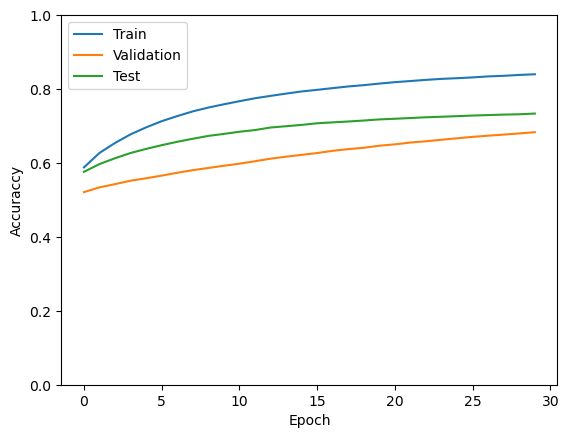

In [36]:
import numpy as np

IN  = 80
H1  = 40
H2  = 20
H3  = 20

def relu(x):
    return np.maximum(0.0, x)

def relu_grad(x):
    return (x > 0.0).astype(np.float64)

def sigmoid_scalar(z):
    z = np.float64(z)
    if z >= 0.0:
        ez = np.exp(-z)
        return 1.0 / (1.0 + ez)
    else:
        ez = np.exp(z)
        return ez / (1.0 + ez)

class STM32FFNN:
    def __init__(self, lr=1e-3):
        self.lr = np.float64(lr)
        self.theta1 = np.float64(H1)
        self.theta2 = np.float64(H2)
        self.theta3 = np.float64(H3)

        lim1 = np.sqrt(6.0 / IN)
        lim2 = np.sqrt(6.0 / H1)
        lim3 = np.sqrt(6.0 / H2)

        self.W1 = np.random.uniform(-lim1, lim1, (H1, IN)).astype(np.float64)
        self.b1 = np.zeros(H1, dtype=np.float64)

        self.W2 = np.random.uniform(-lim2, lim2, (H2, H1)).astype(np.float64)
        self.b2 = np.zeros(H2, dtype=np.float64)

        self.W3 = np.random.uniform(-lim3, lim3, (H3, H2)).astype(np.float64)
        self.b3 = np.zeros(H3, dtype=np.float64)

    def predict(self, x):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)

        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)

        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)

        goodness_1 = np.sum(a1 * a1)
        goodness_2 = np.sum(a2 * a2)
        goodness_3 = np.sum(a3 * a3)

        GOODNESS = goodness_1 + goodness_2 + goodness_3
        THETA = self.theta1 + self.theta2 + self.theta3

        return float(sigmoid_scalar(GOODNESS - THETA))

    def nn_ff_train_one(self, x, y_int8):
        x = np.asarray(x, dtype=np.float64)
        assert x.shape == (IN,)

        y_int = 1 if int(y_int8) != 0 else 0
        loss_sum = np.float64(0.0)

        # Layer1
        z1 = self.b1 + self.W1 @ x
        a1 = relu(z1)
        goodness_1 = np.sum(a1 * a1)

        tmp = (self.theta1 - goodness_1) if y_int else (goodness_1 - self.theta1)
        if tmp > (11.9 - 6.9):
            loss_1 = tmp
        elif tmp < (6.9 - 11.9):
            loss_1 = np.exp(tmp)
        else:
            loss_1 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_1

        dL_dg = (-sigmoid_scalar(self.theta1 - goodness_1)) if y_int else (sigmoid_scalar(goodness_1 - self.theta1))

        t1 = dL_dg * (2.0 * a1) * relu_grad(z1)
        self.b1 -= self.lr * t1
        self.W1 -= self.lr * np.outer(t1, x)

        a1_next = relu(self.b1 + self.W1 @ x)
        # a1_next = a1

        # Layer2
        z2 = self.b2 + self.W2 @ a1
        a2 = relu(z2)
        goodness_2 = np.sum(a2 * a2)

        tmp = (self.theta2 - goodness_2) if y_int else (goodness_2 - self.theta2)
        if tmp > (11.9 - 6.9):
            loss_2 = tmp
        elif tmp < (6.9 - 11.9):
            loss_2 = np.exp(tmp)
        else:
            loss_2 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_2

        dL_dg = (-sigmoid_scalar(self.theta2 - goodness_2)) if y_int else (sigmoid_scalar(goodness_2 - self.theta2))

        t2 = dL_dg * (2.0 * a2) * relu_grad(z2)
        self.b2 -= self.lr * t2
        self.W2 -= self.lr * np.outer(t2, a1_next)

        a2_next = relu(self.b2 + self.W2 @ a1_next)
        # a2_next = a2

        # Layer3
        z3 = self.b3 + self.W3 @ a2
        a3 = relu(z3)
        goodness_3 = np.sum(a3 * a3)

        tmp = (self.theta3 - goodness_3) if y_int else (goodness_3 - self.theta3)
        if tmp > (11.9 - 6.9):
            loss_3 = tmp
        elif tmp < (6.9 - 11.9):
            loss_3 = np.exp(tmp)
        else:
            loss_3 = np.log(1.0 + np.exp(tmp))
        loss_sum += loss_3

        dL_dg = (-sigmoid_scalar(self.theta3 - goodness_3)) if y_int else (sigmoid_scalar(goodness_3 - self.theta3))

        t3 = dL_dg * (2.0 * a3) * relu_grad(z3)
        self.b3 -= self.lr * t3
        self.W3 -= self.lr * np.outer(t3, a2_next)

        return float(loss_sum)


ff = STM32FFNN(lr=1e-5)

epochs = 30
log_size = 2000

train_log = []
validation_log = []
test_log = []

for epoch in range(epochs):
    running_loss = 0.0
    running_correct = 0

    for i in range(len(train_X)):

        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        true = 1 if int(train_y[i]) != 0 else 0
        running_correct += (pred == true)

        loss = ff.nn_ff_train_one(train_X[i], train_y[i])
        running_loss += loss

        if (i + 1) % log_size == 0:
            print(f"epoch {epoch}, step {i+1}: "
                  f"avg_loss={running_loss/log_size:.6f}, acc={running_correct/log_size:.4f}")
            running_loss = 0.0
            running_correct = 0

    train_correct = 0
    preds = []
    for i in range (len(train_X)):
        prob = ff.predict(train_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(train_y[i]) != 0 else 0
        if pred == true:
            train_correct += 1
    train_log.append(train_correct/len(train_X))
    print(f"\033[1mTrain Acc: {train_correct/len(train_X):.6f}\033[0m")

    val_correct = 0
    preds = []
    for i in range (len(val_X)):
        prob = ff.predict(val_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        true = 1 if int(val_y[i]) != 0 else 0
        if pred == true:
            val_correct += 1
    validation_log.append(val_correct/len(val_X))
    print(f"\033[1mValidation Acc: {val_correct/len(val_X):.6f}\033[0m")

    test_correct = 0
    preds = []
    test_preds = []
    for i in range (len(test_X)):
        prob = ff.predict(test_X[i])
        pred = 1 if prob > 0.5 else 0
        preds.append(pred)
        if pred == int(test_y[i]):
            test_correct += 1
    test_log.append(test_correct/len(test_X))
    print(f"\033[1mTest Acc: {test_correct/len(test_X):.6f}\033[0m")


plt.figure()
plt.plot(train_log, label='Train')
plt.plot(validation_log, label='Validation')
plt.plot(test_log, label='Test')
plt.ylim(0, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuraccy')
plt.legend()
plt.show()